<div style="direction: rtl; line-height: 300%;">
  <font face="XB Zar" size="5">
    <div align="center">
      <font face="IranNastaliq" size="30">
        <p></p>
      </font>
    </div>
    <br>
    <div align="center">
      <font color="brown" size="6">
        معین حسن پور - 40032313
      </font>
    </div>
    <br>
    <div align="center">
      <font color="navy">
        <b><u>تمرین سوم</u> طراحی فیلتر مناسب برای پردازش تصویر</b> 
      </  
 <hr>
  </font>
</div>
 <hr>
  </font>
</div>


<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px; color:green;">
１ -با توجه به شکل ۱ -ب به عنوان فیلتر شده تصویر ۱-الف نوع فیلتر و اندازه را با ارایه دالیلی مشخص کنید. سپس فیلتر مورد 
نظر را بر روی تصویر ۱ج اعمال کنید و نتیجه را نشان دهید.
</div>


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px;">
تصویر اصلی و تصویر فیلتر شده(1-ب) در زیر به همراه هیستوگرام تصاویر مربوطه تمایش داده شده اند.<br>
    -->به دلیل مقایسه دقیق تصاویر، تمام هیستوگرام ها نرمال سازی شده اند.
</div>


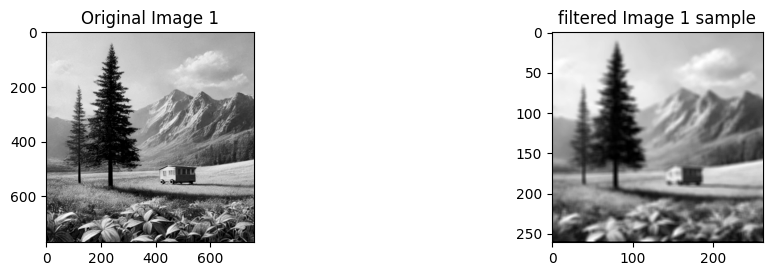

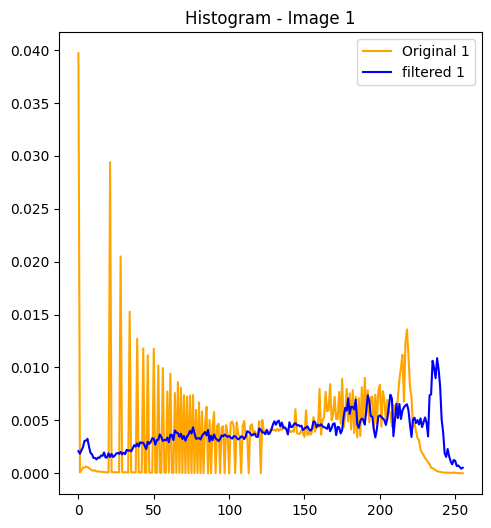

In [11]:
image1 = cv2.imread('1.PNG', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('F1-Filtered.png', cv2.IMREAD_GRAYSCALE)

hist_image1 = cv2.calcHist([image1], [0], None, [256], [0, 256])
hist_blurred_sample = cv2.calcHist([image2], [0], None, [256], [0, 256])
hist_image1 /= hist_image1.sum()
hist_blurred_sample /= hist_blurred_sample.sum()

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(image1, cmap='gray')
plt.title('Original Image 1')

plt.subplot(2, 2, 2)
plt.imshow(image2 , cmap='gray')
plt.title('filtered Image 1 sample')

plt.show()

# نمایش هیستوگرام‌ها
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(hist_image1, color='orange', label='Original 1')
plt.plot(hist_blurred_sample, color='blue', label='filtered 1')
plt.title('Histogram - Image 1')
plt.legend()

plt.show()


<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px;">
سه فیلتر اصلی(میانگین-گاوسی-میانه) را بر روی تصویر اعمال میکنیم تا ببینیم کدام هیسوتگرام تصویر بدست آمده بعد از اعمال  فیلتر ها، با هیستوگزام نمونه مطابقت یبشتری دارد:
</div>


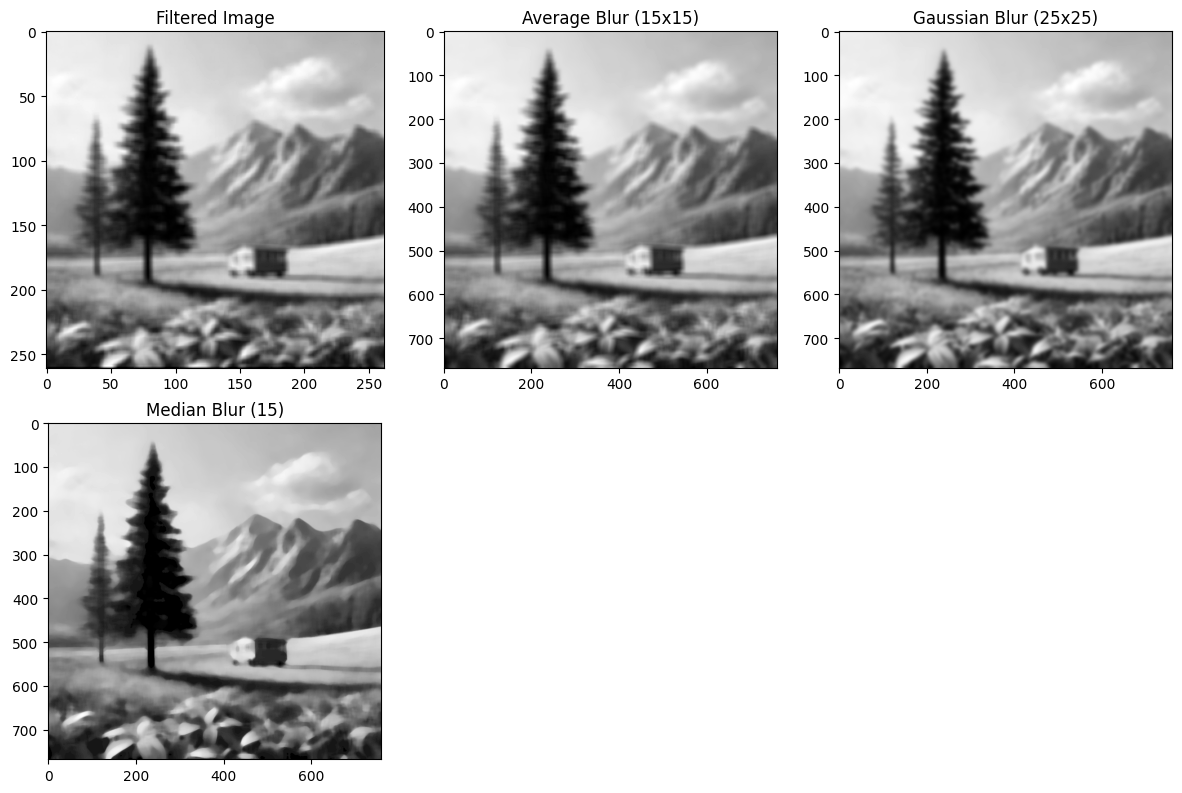

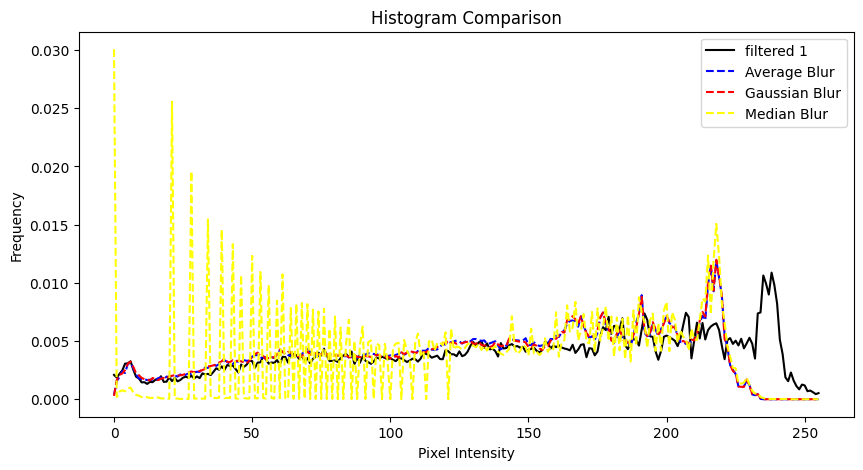

In [17]:
image = cv2.imread("1.PNG", cv2.IMREAD_GRAYSCALE) 

# بررسی عدم وجود تصویر
if image is None:
    print("خطا: تصویر یافت نشد!")
    exit()

# اعمال فیلترهای مختلف برای تار کردن تصویر
blur_avg = cv2.blur(image, (15, 15))  # فیلتر میانگین
blur_gaussian = cv2.GaussianBlur(image, (25, 25), 0)  # فیلتر گاوسی
blur_median = cv2.medianBlur(image, 15)  # فیلتر میانه

# محاسبه هیستوگرام‌ها
def calc_hist(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist /= hist.sum()  # نرمال‌سازی
    return hist

hist_avg = calc_hist(blur_avg)
hist_gaussian = calc_hist(blur_gaussian)
hist_median = calc_hist(blur_median)


# نمایش تصاویر فیلتر شده
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image2 , cmap='gray')
plt.title("Filtered Image")

plt.subplot(2, 3, 2)
plt.imshow(blur_avg, cmap="gray")
plt.title("Average Blur (15x15)")

plt.subplot(2, 3, 3)
plt.imshow(blur_gaussian, cmap="gray")
plt.title("Gaussian Blur (25x25)")

plt.subplot(2, 3, 4)
plt.imshow(blur_median, cmap="gray")
plt.title("Median Blur (15)")


plt.tight_layout()
plt.show()

# نمایش هیستوگرام‌ها
plt.figure(figsize=(10, 5))
plt.plot(hist_blurred_sample, color='black', label='filtered 1')
plt.plot(hist_avg, color="blue", linestyle="dashed", label="Average Blur")
plt.plot(hist_gaussian, color="red", linestyle="dashed", label="Gaussian Blur")
plt.plot(hist_median, color="yellow", linestyle="dashed", label="Median Blur")
plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px;">
با توجه به تحلیل نمودار بالا قطعا یکی از دو فیلتر گاوسین یا میانگین اعمال شده. به بررسی دقیق تر این دو میپردازیم:
</div>


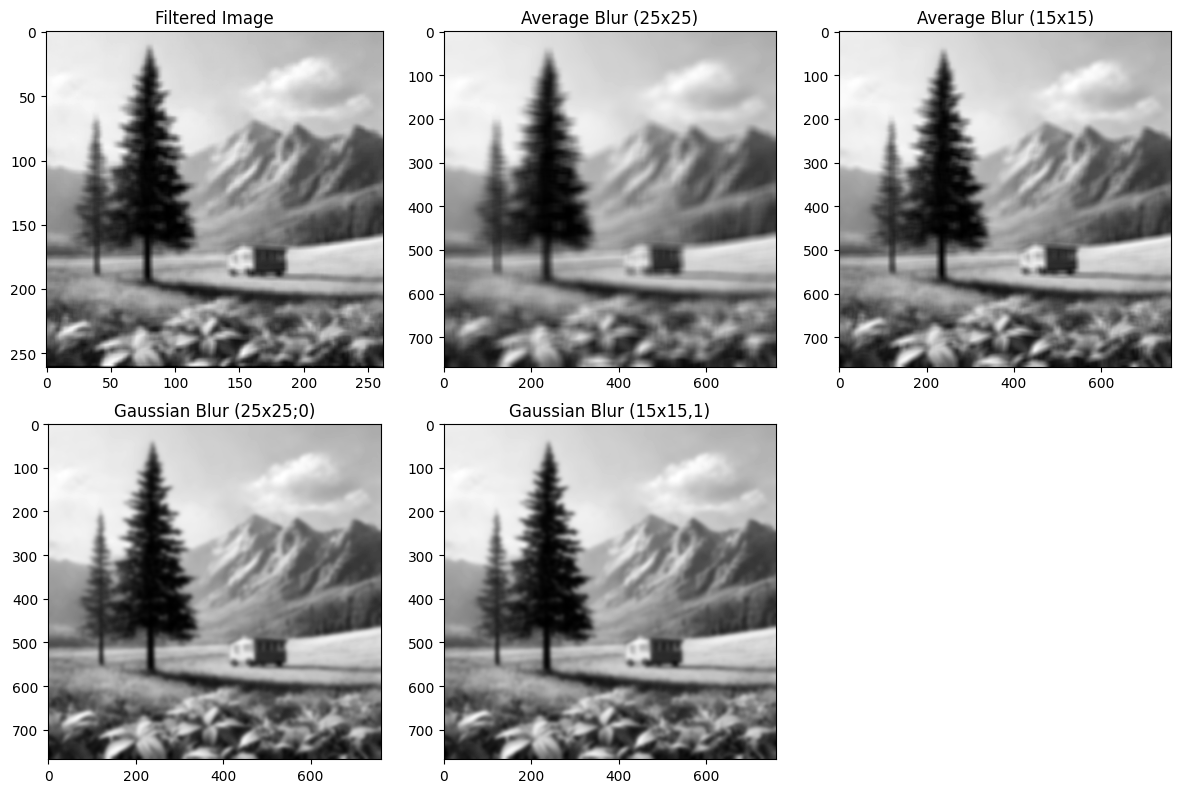

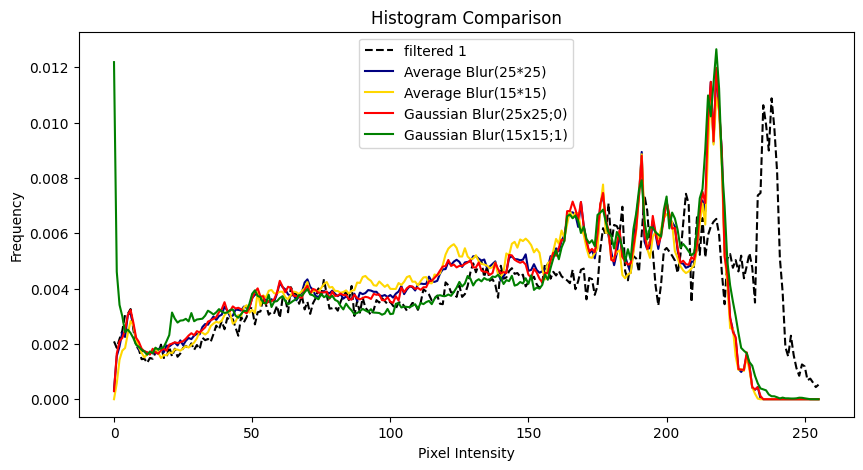

In [28]:
image = cv2.imread("1.PNG", cv2.IMREAD_GRAYSCALE) 

# بررسی عدم وجود تصویر
if image is None:
    print("خطا: تصویر یافت نشد!")
    exit()

blur_avg1 = cv2.blur(image, (15, 15))  
blur_avg2 = cv2.blur(image, (21, 21))  

blur_gaussian1 = cv2.GaussianBlur(image, (25, 25), 0)  # فیلتر گاوسی
blur_gaussian2 = cv2.GaussianBlur(image, (15, 15), 1)  # فیلتر گاوسی

# محاسبه هیستوگرام‌ها
def calc_hist(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist /= hist.sum()  # نرمال‌سازی
    return hist

hist_avg1 = calc_hist(blur_avg1)
hist_avg2 = calc_hist(blur_avg2)
hist_gaussian1 = calc_hist(blur_gaussian1)
hist_gaussian2 = calc_hist(blur_gaussian2)


# نمایش تصاویر فیلتر شده
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image2 , cmap='gray')
plt.title("Filtered Image")

plt.subplot(2, 3, 2)
plt.imshow(blur_avg2, cmap="gray")
plt.title("Average Blur (25x25)")

plt.subplot(2, 3, 3)
plt.imshow(blur_avg1, cmap="gray")
plt.title("Average Blur (15x15)")

plt.subplot(2, 3, 4)
plt.imshow(blur_gaussian1, cmap="gray")
plt.title("Gaussian Blur (25x25;0)")

plt.subplot(2, 3, 5)
plt.imshow(blur_gaussian1, cmap="gray")
plt.title("Gaussian Blur (15x15,1)")

plt.tight_layout()
plt.show()

# نمایش هیستوگرام‌ها
plt.figure(figsize=(10, 5))
plt.plot(hist_blurred_sample, color='black' ,linestyle="dashed" , label='filtered 1')
plt.plot(hist_avg1 , label="Average Blur(25*25)", color='navy')
plt.plot(hist_avg2 , label="Average Blur(15*15)", color='gold')
plt.plot(hist_gaussian1, label="Gaussian Blur(25x25;0)", color='red')
plt.plot(hist_gaussian2, label="Gaussian Blur(15x15;1)", color='green')
plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px;">
با توجه به نتایج بدست آمده و بررسی مقادیر ابتدایی هیستوگرام ها،فلتر اعمال شده به احتمال زیاد از نوع <b>فیلتر میانگین</b> است. <br>اکنون این فیلتر را بر روی تصویر 1-ج اعمال میکنیم:</div>


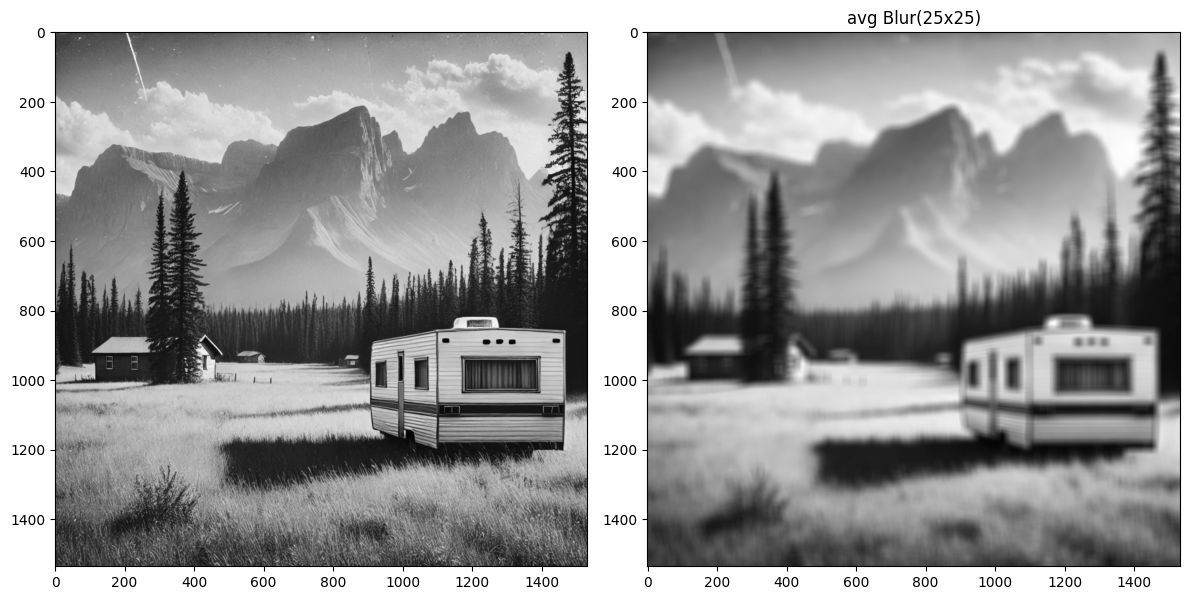

In [31]:
image_C = cv2.imread('gray_image.jpg', cv2.IMREAD_GRAYSCALE) 

blur_avg_C = cv2.blur(image_C, (25, 25)) 

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(image_C , cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(blur_avg_C , cmap='gray')
plt.title("avg Blur(25x25)")
plt.tight_layout()
plt.show()


<hr>
<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px; color:green;">
۲ -همانند تمرین ۱ ، با توجه به فیلتر بکار رفته در شکل ۲ الف ، نوع فیلتر را مشخص کنید <br>سپس با اعمال آن بر روی شکل ۱-ج 
نتیجه را در شکل ۲-ب نشان دهید.
</div>


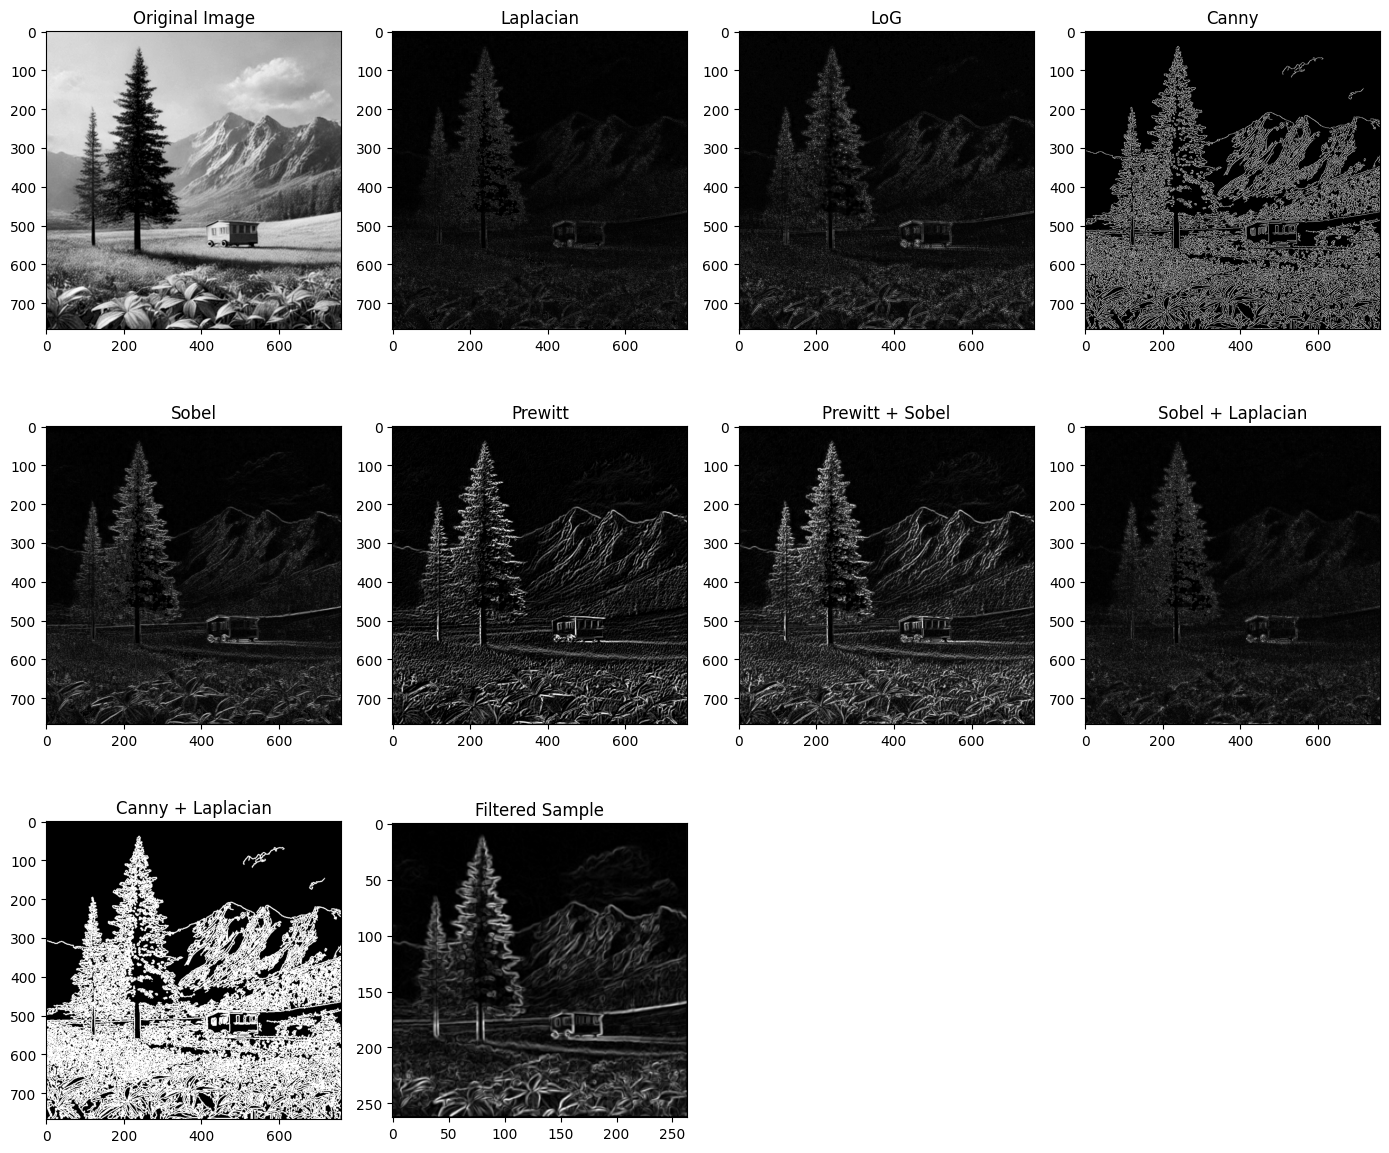

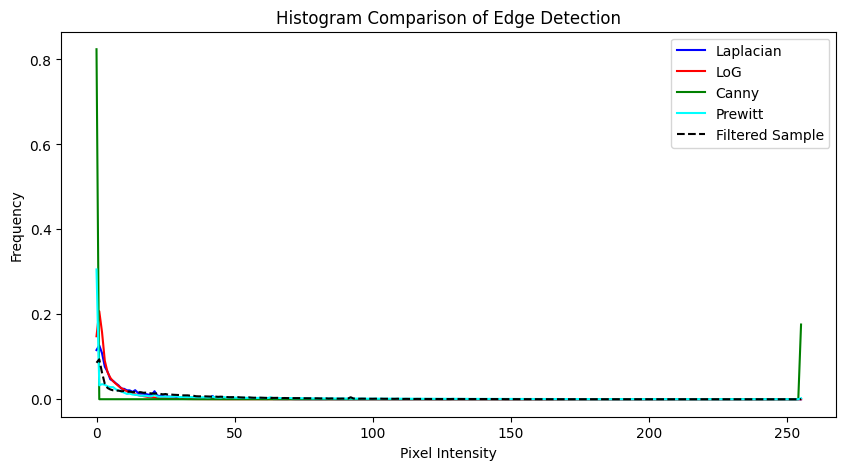

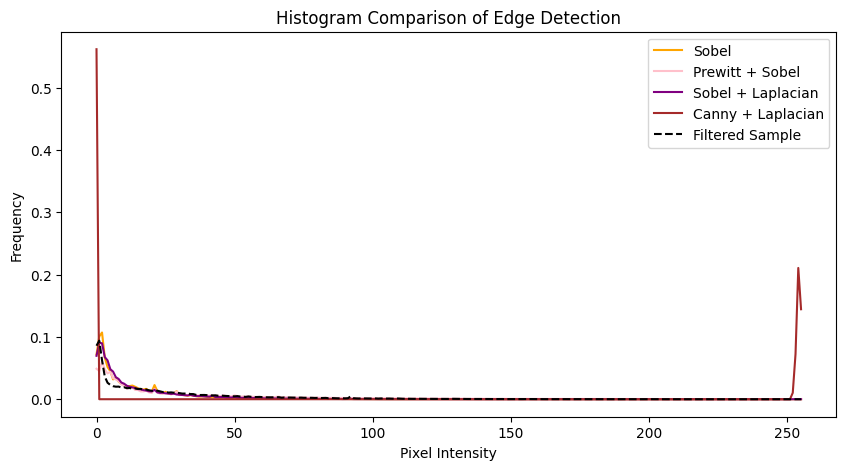

In [49]:
# خواندن تصویر نمونه و تبدیل به خاکستری
image = cv2.imread("1.PNG", cv2.IMREAD_GRAYSCALE)
image_filtered2 = cv2.imread('F1-Filtered2.png', cv2.IMREAD_GRAYSCALE)

# بررسی عدم وجود تصویر
if image is None:
    print("خطا: تصویر یافت نشد!")
    exit()

# فیلتر لاپلاس
laplacian = cv2.Laplacian(image, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# فیلتر لاپلاس گوسی
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 1)
laplacian_of_gaussian = cv2.Laplacian(gaussian_blur, cv2.CV_64F)
laplacian_of_gaussian = np.uint8(np.absolute(laplacian_of_gaussian))

# فیلتر Canny
canny_edges = cv2.Canny(image, 30, 130)

# فیلتر سوبل (X و Y و ترکیب آن‌ها)
sobelx = cv2.Sobel(image, cv2.CV_64F, 2, 0, ksize=1)
sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=1)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_combined = np.uint8(sobel_combined)

# فیلتر پرویت (X و Y و ترکیب آن‌ها)
prewittx = cv2.filter2D(image, -1, np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]))
prewitty = cv2.filter2D(image, -1, np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]]))
prewitt_combined = cv2.magnitude(prewittx.astype(np.float64), prewitty.astype(np.float64))
prewitt_combined = np.uint8(prewitt_combined)

# فیلتر پرویت + سوبل
prewitt_sobel_combined = cv2.magnitude(prewitt_combined.astype(np.float64), sobel_combined.astype(np.float64))
prewitt_sobel_combined = np.uint8(prewitt_sobel_combined)

# فیلتر سوبل + لاپلاس
laplacian_of_sobel = cv2.Laplacian(sobel_combined, cv2.CV_64F)
laplacian_of_sobel = np.uint8(np.absolute(laplacian_of_sobel))

# فیلتر Canny + لاپلاس
laplacian_of_canny = cv2.Laplacian(canny_edges, cv2.CV_64F)
laplacian_of_canny = np.uint8(np.absolute(laplacian_of_canny))

# تابع محاسبه هیستوگرام
def calc_hist(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist /= hist.sum()
    return hist

# محاسبه هیستوگرام‌ها
hist_laplacian = calc_hist(laplacian)
hist_log = calc_hist(laplacian_of_gaussian)
hist_canny = calc_hist(canny_edges)
hist_sobel = calc_hist(sobel_combined)
hist_prewitt = calc_hist(prewitt_combined)
hist_prewitt_sobel = calc_hist(prewitt_sobel_combined)
hist_lap_sobel = calc_hist(laplacian_of_sobel)
hist_lap_canny = calc_hist(laplacian_of_canny)
hist_sample = calc_hist(image_filtered2)

# نمایش تصاویر فیلتر شده
plt.figure(figsize=(14, 12))

plt.subplot(3, 4, 1), plt.imshow(image, cmap='gray'), plt.title("Original Image")
plt.subplot(3, 4, 2), plt.imshow(laplacian, cmap='gray'), plt.title("Laplacian")
plt.subplot(3, 4, 3), plt.imshow(laplacian_of_gaussian, cmap='gray'), plt.title("LoG")
plt.subplot(3, 4, 4), plt.imshow(canny_edges, cmap='gray'), plt.title("Canny")
plt.subplot(3, 4, 5), plt.imshow(sobel_combined, cmap='gray'), plt.title("Sobel")
plt.subplot(3, 4, 6), plt.imshow(prewitt_combined, cmap='gray'), plt.title("Prewitt")
plt.subplot(3, 4, 7), plt.imshow(prewitt_sobel_combined, cmap='gray'), plt.title("Prewitt + Sobel")
plt.subplot(3, 4, 8), plt.imshow(laplacian_of_sobel, cmap='gray'), plt.title("Sobel + Laplacian")
plt.subplot(3, 4, 9), plt.imshow(laplacian_of_canny, cmap='gray'), plt.title("Canny + Laplacian")
plt.subplot(3, 4, 10), plt.imshow(image_filtered2, cmap='gray'), plt.title("Filtered Sample")

plt.tight_layout()
plt.show()

# نمایش هیستوگرام‌ها
plt.figure(figsize=(10, 5))
plt.plot(hist_laplacian, label="Laplacian", color='blue')
plt.plot(hist_log, label="LoG", color='red')
plt.plot(hist_canny, label="Canny", color='green')
plt.plot(hist_prewitt, label="Prewitt", color='cyan')
plt.plot(hist_sample, label="Filtered Sample", color='black', linestyle="dashed")
plt.title("Histogram Comparison of Edge Detection")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(hist_sobel, label="Sobel", color='orange')
plt.plot(hist_prewitt_sobel, label="Prewitt + Sobel", color='pink')
plt.plot(hist_lap_sobel, label="Sobel + Laplacian", color='purple')
plt.plot(hist_lap_canny, label="Canny + Laplacian", color='brown')
plt.plot(hist_sample, label="Filtered Sample", color='black', linestyle="dashed")
plt.title("Histogram Comparison of Edge Detection")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


<div dir="rtl" style="text-align: right; font-size: 18px; font-family: Tahoma, Arial, sans-serif; line-height: 1.8; padding: 10px; border-radius: 10px;">
ظبق نتایح بدست آمده بیشترین شباهت به نمونه مورد نظر در فیلتر سوبل رقم خورده است. 
<br>اعمال فیلتر سوبل بر روی تصویر 1-ج:</div>


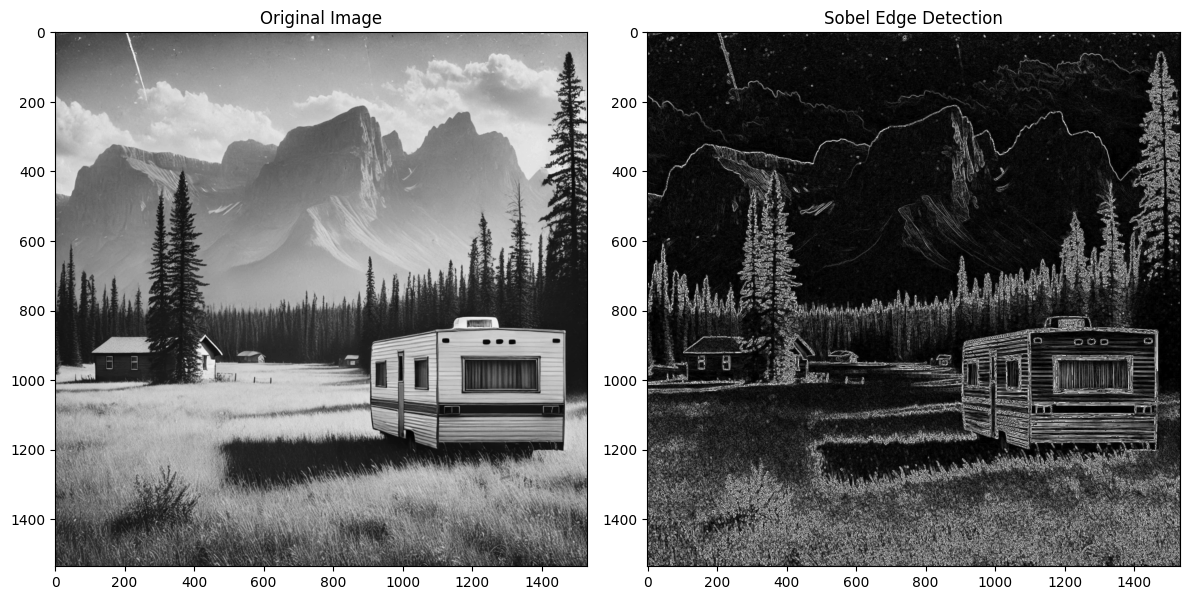

In [51]:
# اعمال فیلتر سوبل در جهت X و Y
sobelx = cv2.Sobel(image_C, cv2.CV_64F, 1, 0, ksize=3)  
sobely = cv2.Sobel(image_C, cv2.CV_64F, 0, 1, ksize=3)  

# ترکیب لبه‌های افقی و عمودی
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_combined = np.uint8(sobel_combined)  # تبدیل به 8 بیتی برای نمایش

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(image_C, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(sobel_combined, cmap='gray')
plt.title("Sobel Edge Detection")

plt.tight_layout()
plt.show()
